root is the path where the train/test data is stored,

train specifies training or test dataset,

download=True downloads the data from the internet if it’s not available at root.

transform
    transform=ToTensor()

    This modifies the INPUT data (features).
    Usually used to:
    convert images to tensors,
    normalize images,
    resize images,
    augment data.

target_transform
    target_transform=
    this moddifies the lables(targets)
    exemple:
        convert labels
        encode categories
        apply custom mapping

Image ---> transform ----------> Tensor
Label ---> target_transform ---> Modified Label

In [1]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import v2
import matplotlib.pyplot as plt

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.ToTensor(),
    target_transform=v2.ToDtype(torch.float32, scale=True),
)


test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.ToTensor(),
    target_transform=v2.ToDtype(torch.float32, scale=True),
)

/home/mohamed-amine/Documents/pytorch_course/p_venv/lib/python3.12/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100.0%
100.0%
100.0%
100.0%


Iterating and Visualizing the Datase
You can access elements inside the dataset using an index:
    training_data[index]
    image, label = training_data[0]
    =>the first image ,its lables from the datasets


Why This Works
Because PyTorch datasets implement:
    __getitem__()
So when you write:
    training_data[0]
PyTorch internally does:
    training_data.__getitem__(0)

This code displays random images from the FashionMNIST using Matplotlib.

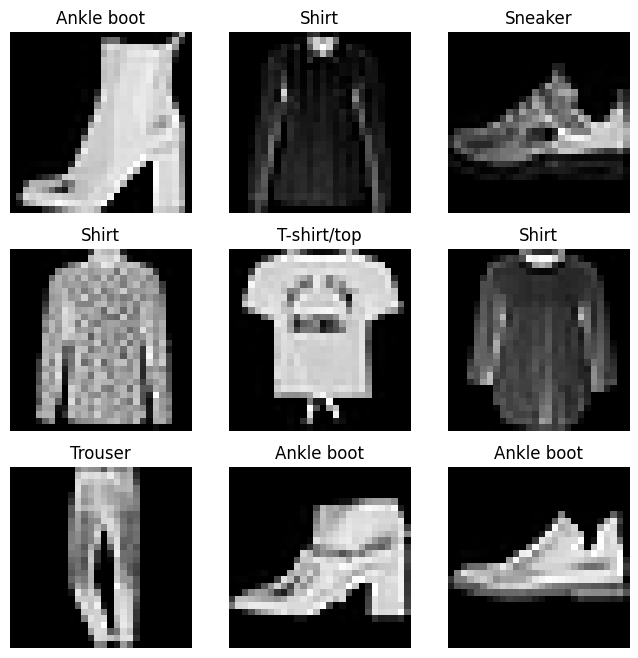

In [2]:
labels_map = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot",
}
#dictionary convert numeric lables into readable names
figure = plt.figure(figsize=(8,8))
# create a figure with a specific size width 8 inches and height 8 inches
cols, rows = 3, 3
#grid of 3 columns and 3 rows(total 9 images)


for i in range(1, cols*rows +1):   # [1..9]
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    #generate a random index to select a sample from the training data
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    #add a subplot to the figure at the specified position (i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

Creating a Custom Dataset for your files
creating other class extend Dataset 
A custom Dataset class must implement three functions: __init__, __len__, and __getitem__. Take a look at this implementation; the FashionMNIST images are stored in a directory img_dir, and their labels are stored separately in a CSV file annotations_file.

In the next sections, we’ll break down what’s happening in each of these functions.

Parameters:
annotations_file → CSV file (image names + labels)
img_dir → folder where images are stored
transform → preprocessing for images (resize, normalize)
target_transform → preprocessing for labels

In [16]:
import os 
import pandas as pd 
from torch.utils.data import Dataset
from torchvision.io import decode_image

class CustomImageDataset(Dataset):
    def __init__(self,annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform


    def __len__(self):
        return len(self.img_labels)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = decode_image(img_path)
        label = self.img_labels.iloc[idx, 1]

        if self.transform:
            image = self.transform(image) #resize normalize ,augmentation
        
        if self.target_transform:
            label = self.target_transform(label)
            #convert label to tensor one-hot encoding
        
        return image ,label
            


In [17]:
dataset = CustomImageDataset("labels.csv", "images/")

In [18]:
img, label = dataset[0]

print(img)
print(label)

tensor([[[ 45,  45,  45,  ...,  45,  45,  45],
         [ 45,  45,  45,  ...,  45,  45,  45],
         [ 45,  45,  45,  ...,  45,  45,  45],
         ...,
         [ 45,  45,  45,  ...,  45,  45,  45],
         [ 45,  45,  45,  ...,  45,  45,  45],
         [ 45,  45,  45,  ...,  45,  45,  45]],

        [[135, 135, 135,  ..., 135, 135, 135],
         [135, 135, 135,  ..., 135, 135, 135],
         [135, 135, 135,  ..., 135, 135, 135],
         ...,
         [135, 135, 135,  ..., 135, 135, 135],
         [135, 135, 135,  ..., 135, 135, 135],
         [135, 135, 135,  ..., 135, 135, 135]],

        [[ 30,  30,  30,  ...,  30,  30,  30],
         [ 30,  30,  30,  ...,  30,  30,  30],
         [ 30,  30,  30,  ...,  30,  30,  30],
         ...,
         [ 30,  30,  30,  ...,  30,  30,  30],
         [ 30,  30,  30,  ...,  30,  30,  30],
         [ 30,  30,  30,  ...,  30,  30,  30]],

        [[255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         [25

__init__
The __init__ function is run once when instantiating the Dataset object. We initialize the directory containing the images, the annotations file, and both transforms (covered in more detail in the next section).

__getitem__
The __getitem__ function loads and returns a sample from the dataset at the given index idx. Based on the index, it identifies the image’s location on disk, converts that to a tensor using decode_image, retrieves the corresponding label from the csv data in self.img_labels, calls the transform functions on them (if applicable), and returns the tensor image and corresponding label in a tuple.

#Preparing your data for training with DataLoaders

The Dataset retrieves our dataset’s features and labels one sample at a time. While training a model, we typically want to pass samples in “minibatches”, reshuffle the data at every epoch to reduce model overfitting, and use Python’s multiprocessing to speed up data retrieval.

DataLoader is an iterable that abstracts this complexity for us in an easy API.

In [ ]:
#we work on the data fashionMNIST dataset which is already in the form 
# of a PyTorch dataset and we can use it directly with a dataloader

from torch.utils.data import DataLoader
train_dataloader = DataLoader(training_data, batch_size=64, shuffle= True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle= False)

Iterate through the DataLoader
You first take a Dataset (like FashionMNIST) and wrap it inside a DataLoader:
    So now instead of getting one image at a time, you get groups of images.

“We can iterate through the dataset”
This means you loop over the DataLoader:
    for train_features, train_labels in train_loader:
=>Each loop gives you a batch.

A batch is a small group of samples.
batch_size = 64
So each iteration returns:

    64 images (features)
    64 labels

Why use batches?

Instead of processing 1 image at a time:

✔ Faster training
✔ Uses GPU efficiently
✔ More stable learning

shuffle=True
    The dataset is randomly mixed before forming batches.
    Why shuffle is important

    Without shuffle:
    model sees data in fixed order
    it can memorize patterns incorrectly

    With shuffle:
    ✔ improves generalization
    ✔ avoids learning order bias

After we iterate over all batches, the data is shuffled again
    Each epoch:

    Data is shuffled
    New batches are created
    Model trains again

epoch: one full pass over the dataset

for fashionMinust :
steps per epoch = 60000/64 =937
so each epch has 937 batches


Simple Analogy

Think of a DataLoader like a factory:
Dataset = all raw materials
DataLoader = machine that:
mixes materials (shuffle)
packs them into boxes (batches of 64)
sends them to the model

This code shows how to take one batch of data from a DataLoader in PyTorch and display one image from it.


iter(train_dataloader) → creates an iterator (a stream of batches)
next(...) → takes one batch only
=>So you are NOT looping through all data, only grabbing the first batch.

You get:
train_features → batch of images(64 images)
train_labels → batch of labels(64 lables)


[64, 1, 28, 28]
    64 images 
    1 color channel(grayscale)
    28*28 pixels

[64]
    64 class labels (one per image)


Select one image from the batch

    train_features[0]
    picks the first image in the batch

    .squeeze()
    Removes extra dimension:

Summary 

    DataLoader → gives batch of 64 images
            ↓
    next(iter(...)) → take 1 batch
            ↓
    train_features[0] → pick first image
            ↓
    squeeze() → fix shape for display
            ↓
    imshow() → show image
            ↓
    print label → show class

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


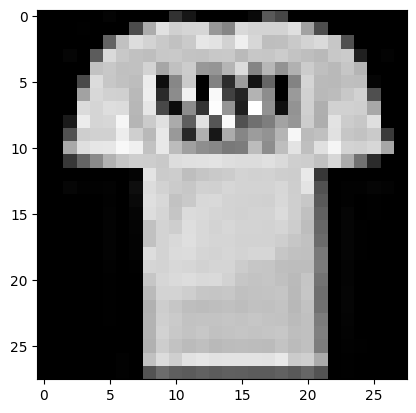

Label: 0


In [20]:
#Display a image from the dataloader 
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img,cmap="gray")
plt.show()
print(f"Label: {label}")

when we collect data , it is often in not in the format that a neural network expects 
for exemple if we take image a nn cannot directly perform calculation on a PIL image .so we need to transfome to tensor 

Label 
suppose we have :
T-shirt = 0
Trouser = 1
Dress = 2
 
the label is a integer 
sometimes we want to convert it into a one-hot vector 
0 -> [1,0,0]
1 -> [0,1,0]
2 -> [0,0,1]


transform vs target_transfom
every torchvsion dataset has two parameters :
    transform
    target_transform
1-transform
    used on the features(images)
    PIL images ----->(transform)----->tensor
2-target_transform
    used on the labels
    Label--->(target_transform)----->tensor

In [2]:
import torch
import torch.nn.functional as F
from torchvision import datasets
from torchvision.transforms import v2

ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
    target_transform=v2.Lambda(
        lambda y: F.one_hot(torch.tensor(y), num_classes=10).float()
    ),
)

ToImage()
converts images to a TorchVision image tensor.


In [3]:
from PIL import Image

img = Image.open("images/dress1.jpg")
print(type(img))

<class 'PIL.PngImagePlugin.PngImageFile'>


neural network cannot work directly with a PIL image.

In [7]:
from torchvision.transforms import v2
transform = v2.ToImage()
img_tensor = transform(img)
print(type(img_tensor))


<class 'torchvision.tv_tensors._image.Image'>


torchvision est une bibliothèque associée à PyTorch pour le traitement d'images et la vision par ordinateur.
transforms contient des transformations d'images (redimensionnement, rotation, normalisation, etc.).\n
v2 est la nouvelle version de l'API des transformations.

v2.TOImage()
ici on cree une object transformation 

est une classe dont le rôle est :
Convertir une image PIL ou un tableau NumPy en un objet Image de torchvision.

La variable transform contient maintenant l'objet transformation.

img_tensor = transform(img)
-->ici on applique la transformation a l'images

In [ ]:
#TODtype(img_tensor)

after ToImage(),pixels are usually betweel 0-255
neural networks usually work better with values between 0.0-1.0

In [ ]:
v2.ToDtype(torch.float32, scale = True)

this object do 2 thing 
step 1:conver dataype (uint8)-->(float32)
step 2: scale values divides by 255. (noramlisation)

In [ ]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale = True)
])
img_tensor = transform(img)
print(type(img_tensor))

<class 'torchvision.tv_tensors._image.Image'>


Lambda Transform:
is a small anoymous function 

in fashionMunist the label is from 0-->9 each one correspond label categoreical so instead of traite 3 (t-shirt) we create  [0.0.0.1.0.0.0.0.0] and this is in definite in target_transformation

In [9]:
target_transform = lambda y:F.one_hot(
    torch.tensor(y),
    num_classes=10
).float()

FULL PIPELINE

In [14]:
import torch
import torch.nn.functional as F
from torchvision import datasets
from torchvision.transforms import v2

transform1 = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale = True)
])

target_transform1 = lambda y:F.one_hot(
    torch.tensor(y),
    num_classes=10
).float()

ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform1,
    target_transform=target_transform1
)
image, label = ds[0]
print(image.shape)
print(label)


torch.Size([1, 28, 28])
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])


for more 
https://docs.pytorch.org/vision/stable/transforms.html#v2-api-reference-recommended

v2-api reference
https://docs.pytorch.org/vision/stable/transforms.html#v2-api-reference-recommended